# Análisis exploratorio de dataset ventas

In [2]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import matplotlib.pyplot as plt
from src.extract import extract_data
from src.transform import clean_data, calculate_metrics, aggregate_sales

## Carga y estructura de datos

In [3]:
df_raw = extract_data("../data/ventas.db")
print(f"Filas: {df_raw.shape[0]} | Columnas: {df_raw.shape[1]}")
df_raw.head()

Filas: 208 | Columnas: 7


,id,fecha,producto,categoria,cantidad,precio_unitario,cliente_id
0,1,2025-11-24,Audífonos,Electrónica,6.0,80.0,16
1,2,2025-04-25,Chaqueta,Ropa,2.0,70.0,44
2,3,2025-10-07,Teclado,Electrónica,7.0,45.0,3
3,4,2025-01-16,Audífonos,Electrónica,1.0,80.0,33
4,5,2025-11-05,Teclado,Electrónica,5.0,45.0,46


In [5]:
df_raw.dtypes

id                   int64
fecha               object
producto            object
categoria           object
cantidad           float64
precio_unitario    float64
cliente_id           int64
dtype: object

## Calidad de los datos

In [6]:
df_raw.isna().sum()

id                 0
fecha              0
producto           0
categoria          0
cantidad           3
precio_unitario    3
cliente_id         0
dtype: int64

In [8]:
columnas_sin_id = [col for col in df_raw.columns if col != "id"]
print(f"Duplicados: {df_raw.duplicated(subset=columnas_sin_id).sum()}")

Duplicados: 8


In [9]:
print(f"Cantidades negativas: {(df_raw['cantidad'] < 0).sum()}")
print(f"Precios <= 0: {(df_raw['precio_unitario'] <= 0).sum()}")
print(f"Fecha mínima: {df_raw['fecha'].min()} | Fecha máxima: {df_raw['fecha'].max()}")
df_raw[["cantidad", "precio_unitario"]].describe()

Cantidades negativas: 0
Precios <= 0: 0
Fecha mínima: 2025-01-02 | Fecha máxima: 2025-12-28


,cantidad,precio_unitario
count,205.000000,205.000000
mean,4.434146,39.614634
std,1.938213,20.062226
min,1.000000,12.000000
25%,3.000000,25.000000
50%,4.000000,35.000000
75%,6.000000,50.000000
max,9.000000,80.000000


## Limpieza de datos

In [10]:
df = calculate_metrics(clean_data(df_raw))
print(f"Total de filas antes: {len(df_raw)} | Total de filas después: {len(df)}")
print(f"Total nulos: {df.isna().sum().sum()}")
df.head()

Total de filas antes: 208 | Total de filas después: 200
Total nulos: 0


,id,fecha,producto,categoria,cantidad,precio_unitario,cliente_id,venta_total,mes
0,1,2025-11-24,Audífonos,Electrónica,6,80.0,16,480.0,11
1,2,2025-04-25,Chaqueta,Ropa,2,70.0,44,140.0,4
2,3,2025-10-07,Teclado,Electrónica,7,45.0,3,315.0,10
3,4,2025-01-16,Audífonos,Electrónica,1,80.0,33,80.0,1
4,5,2025-11-05,Teclado,Electrónica,5,45.0,46,225.0,11


# Análisis exploratorio de datos

## Ventas por categoría

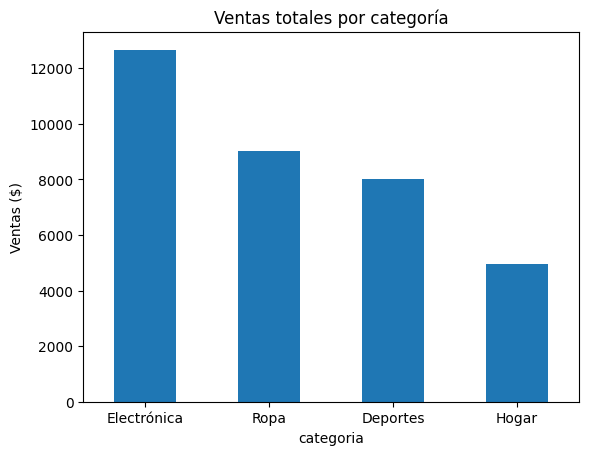

categoria
Electrónica    12663.436548
Ropa            9029.527919
Deportes        8012.000000
Hogar           4949.654822
Name: venta_total, dtype: float64

In [13]:
ventas_categoria = df.groupby("categoria")["venta_total"].sum().sort_values(ascending = False)
ventas_categoria.plot(kind = "bar", title = "Ventas totales por categoría", ylabel = "Ventas ($)", rot = 0)
plt.show()
ventas_categoria

# Tendencia mensual

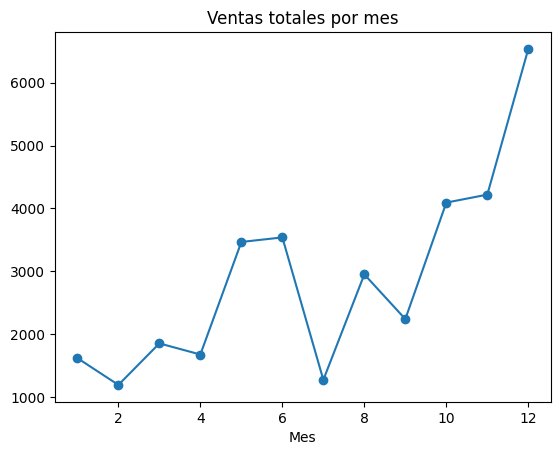

In [15]:
ventas_mes = df.groupby("mes")["venta_total"].sum()
ventas_mes.plot(kind = "line", marker = "o", title = "Ventas totales por mes", xlabel = "Mes")
plt.show()

# Clientes recurrentes

In [16]:
compras_cliente = df["cliente_id"].value_counts()
print(f"Clientes distintos: {compras_cliente.size}")
print(f"Promedio de compras por cliente: {compras_cliente.mean():.1f}")
compras_cliente.head(5)

Clientes distintos: 50
Promedio de compras por cliente: 4.0


cliente_id
23    10
11     8
44     7
37     7
46     6
Name: count, dtype: int64

# Conclusiones

1. En la gráfica de ventas totales por categoría, la categoría con mayor cantidad de ventas es "Electronica" con 12663.44, seguida de "Ropa" con 9029.53, luego "Deportes" con 8012.00, y la que tiene menor cantidad de ventas es "Hogar" con 4949.65.

2. En el diagrame de líneas se evidencia que las ventas tuvieron una tendencia creciente con picos muy fuertes de descenso en los meses 7 y 9. Mientras que los meses 6 y 12 tuvieron la mayor cantidad de ventas realizadas. Asimismo, se permite evidenciar que entre los meses 5 y 6, y 10 y 11, las ventas se mantuvieron casi constantes.

3. En total de 200 registros, se tuvieron 50 clientes distintos donde el promedio total de compra por cliente fue de 4. Los clientes con mayor cantidad de compras son los que de ID: 23, 11, 44, 37 y 46 con 10, 8, 7 y 6 ventas respectivamente.

## Exportación a script

In [18]:
!jupyter nbconvert --to script exploracion.ipynb

[NbConvertApp] Converting notebook exploracion.ipynb to script
[NbConvertApp] Writing 2959 bytes to exploracion.py
